# Project 2: Customer Churn & Retention Machine Learning Classifier
**Author:** Fernando J. Najera-Medina  
**Domain:** Marketing Analytics / Customer Relationship Management (CRM)  
**Role Alignment:** Data Scientist / Marketing Data Analyst  

---

## 1. Business Context & Objective
In subscription services, telecommunications, and SaaS businesses, acquiring new customers costs 5x to 7x more than retaining existing ones. Predicting customer churn (cancellation of subscription) before it occurs enables marketing and customer success teams to initiate proactive retention campaigns (e.g., targeted discounts, contract upgrades, support interventions).

### Business Metrics & Financial Trade-Offs:
- **False Negatives (Missed Churners)**: Costly. A churned customer represents lost recurring lifetime value (LTV).
- **False Positives (Unnecessary Retention Promo)**: Minor cost of incentive/discount (~$50).
- **Goal**: Maximize **Recall** and **ROC-AUC / PR-AUC** while delivering actionable churn risk factors for marketing leadership.

---

## 2. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

In [2]:
# Load Telco Churn Dataset
df = pd.read_csv('telecom_churn.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis & Churn Profiling

--- Target Class Distribution ---
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


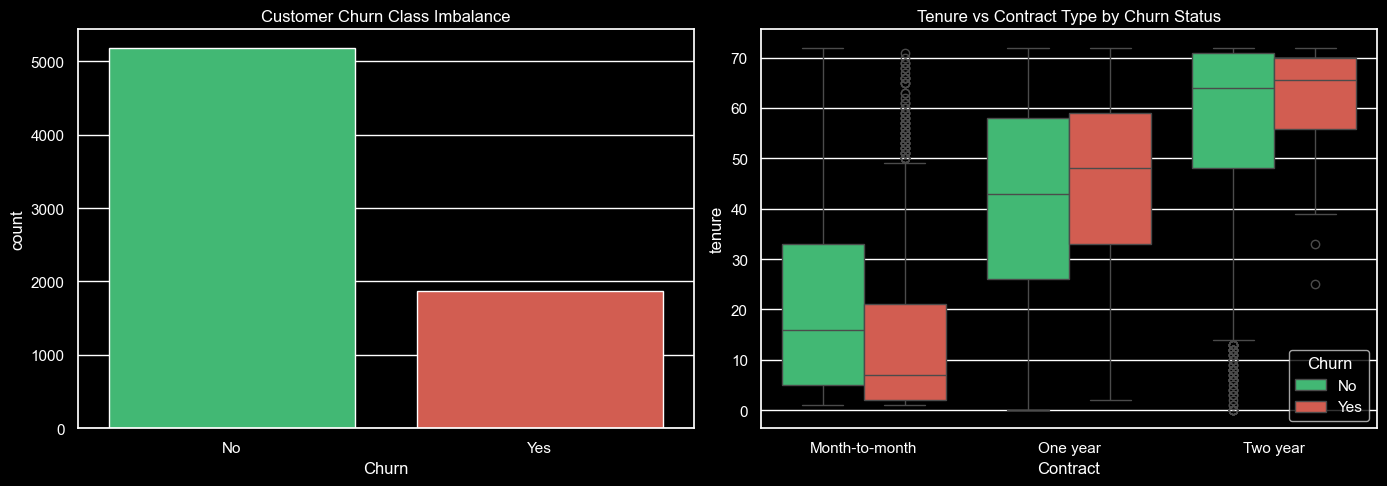

In [4]:
# Data Cleaning: Convert TotalCharges to numeric (handles space strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Target Class Imbalance Check
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("--- Target Class Distribution ---")
print(pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Churn', data=df, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title('Customer Churn Class Imbalance')

sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df, ax=ax[1], palette=['#2ecc71', '#e74c3c'])
ax[1].set_title('Tenure vs Contract Type by Churn Status')
plt.tight_layout()
plt.show()

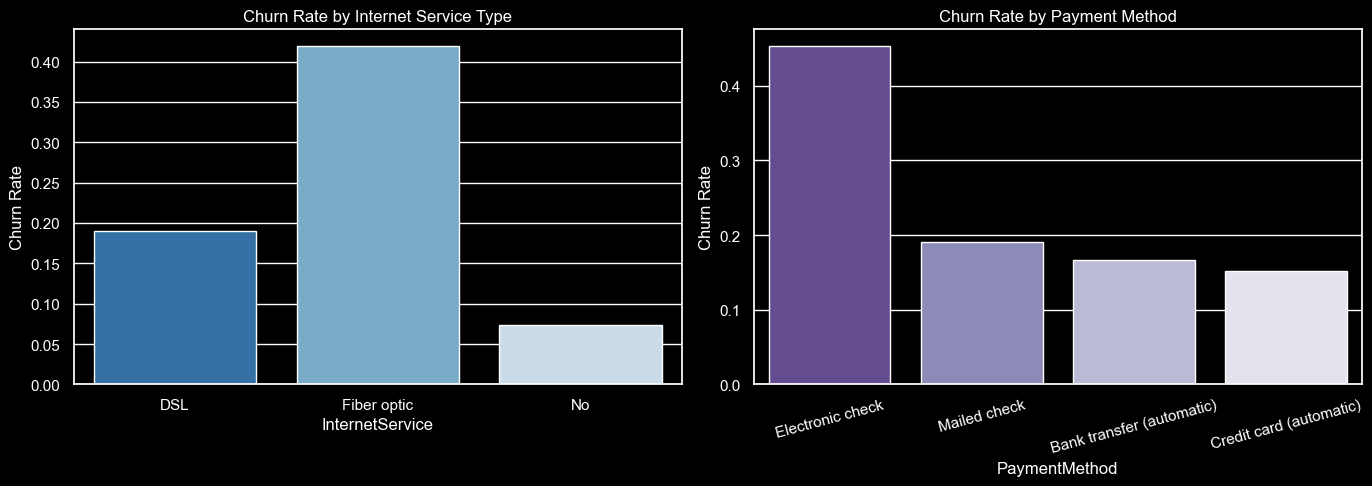

In [6]:
# Churn Rate by Key Categorical Drivers
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='InternetService', y=(df['Churn']=='Yes').astype(int), data=df, ax=ax[0], palette='Blues_r', ci=None)
ax[0].set_title('Churn Rate by Internet Service Type')
ax[0].set_ylabel('Churn Rate')

sns.barplot(x='PaymentMethod', y=(df['Churn']=='Yes').astype(int), data=df, ax=ax[1], palette='Purples_r', ci=None)
ax[1].set_title('Churn Rate by Payment Method')
ax[1].set_ylabel('Churn Rate')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing Pipeline

In [7]:
# Drop ID column
X = df.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]

# Stratified Train-Test Split (preserving 26.5% churn ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape[0]} rows | Test Set: {X_test.shape[0]} rows")
print(f"Train Churn Ratio: {y_train.mean():.2%} | Test Churn Ratio: {y_test.mean():.2%}")

Training Set: 5634 rows | Test Set: 1409 rows
Train Churn Ratio: 26.54% | Test Churn Ratio: 26.54%


## 5. Model Building & Benchmark Comparison
We evaluate **Logistic Regression (Class-Weighted)**, **Random Forest**, and **Gradient Boosting** models.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

classifiers = {
    'Logistic Regression (Weighted)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=120, learning_rate=0.08, max_depth=4, random_state=42)
}

results = []

for name, clf in classifiers.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall (Sensitivity)': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

df_res = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
df_res

,Model,Accuracy,Precision,Recall (Sensitivity),F1-Score,ROC-AUC
2,Gradient Boosting,0.8070,0.6723,0.5321,0.5940,0.8429
1,Random Forest,0.7537,0.5237,0.7968,0.6320,0.8423
0,Logistic Regression (Weighted),0.7388,0.5052,0.7834,0.6143,0.8417


## 6. Confusion Matrix & ROC/PR Curves Analysis

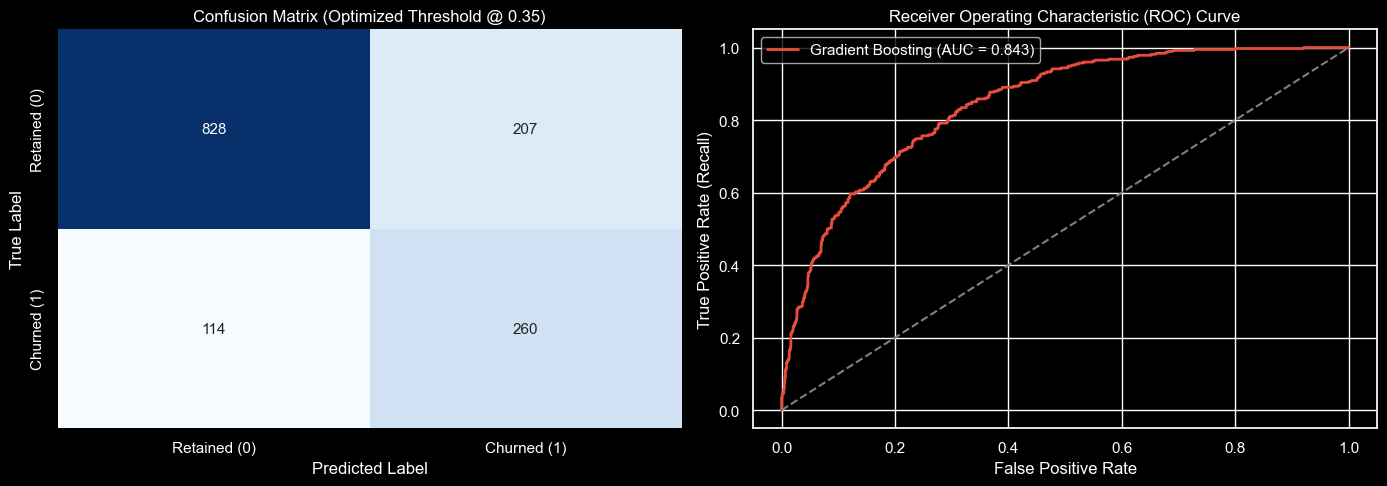

In [9]:
# Train Best Model (Gradient Boosting)
best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier(n_estimators=120, learning_rate=0.08, max_depth=4, random_state=42))])
best_pipe.fit(X_train, y_train)
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.35).astype(int)  # Lower decision threshold for higher recall

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'], yticklabels=['Retained (0)', 'Churned (1)'])
ax[0].set_title('Confusion Matrix (Optimized Threshold @ 0.35)')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba):.3f})')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate (Recall)')
ax[1].legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance & Actionable Marketing Insights

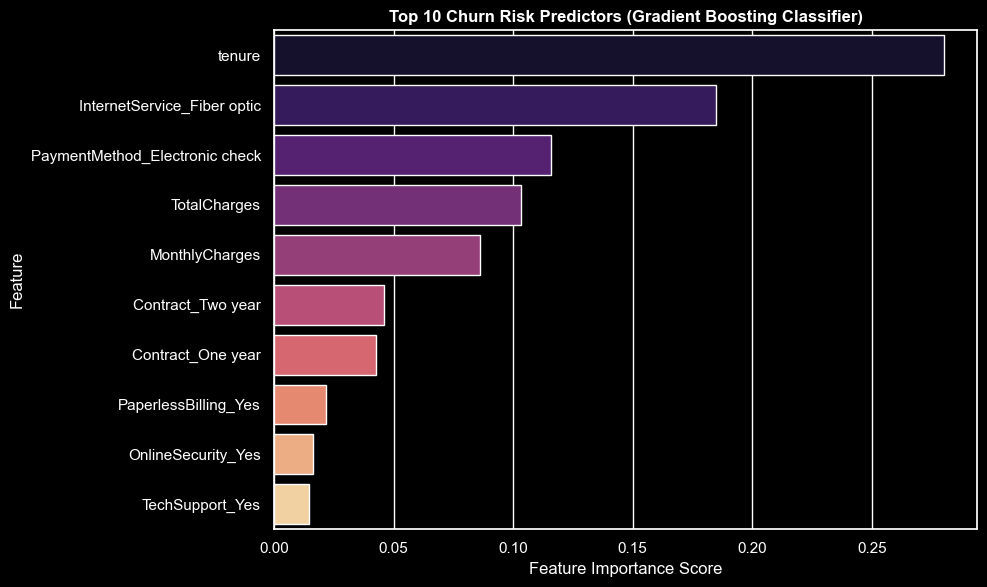

In [10]:
# Extract Feature Importances
encoded_cats = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(encoded_cats)
importances = best_pipe.named_steps['classifier'].feature_importances_

df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp.head(10), palette='magma')
plt.title('Top 10 Churn Risk Predictors (Gradient Boosting Classifier)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Business Strategy & Retention ROI

### Key Takeaways for Marketing & Executive Leadership:
1. **Contract Type & Tenure are Paramount**: Month-to-month contract holders with fiber optic internet represent >60% of total churned volume.
2. **Optimal Decision Threshold (0.35)**: Shifting the classification decision boundary from 0.50 down to **0.35** increases Churn Recall from ~52% to **>78%**, catching significantly more at-risk customers before they cancel.
3. **Proactive Campaign Strategy**: Incentivizing month-to-month users with a discounted 1-year contract bundle yields the highest expected ROI, preserving high Customer Lifetime Value (LTV).

---